Análisis de GPS en Aves

In [1]:
#Importar librerías necesarias
import numpy as np
import time
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
#Importar datos y visualizar
df = pd.read_csv('data_gps.csv')
df = df.drop(columns=['Unnamed: 0'], axis=1)
df.head()

,lat,lon,alt,unix,bird,species,year,date_time,max_depth.m,colony2,coverage_ratio,is_dive,is_dive_1m,is_dive_2m,is_dive_4m,is_dive_5m,is_dive_0m
0,56.095451,-6.233089,-23.059999,1340627854,1,tCOGU,t2012,2012-06-25 13:37:34,-2.172046,1,0.5,False,False,False,False,False,False
1,56.095408,-6.233520,-2.983077,1340627954,1,tCOGU,t2012,2012-06-25 13:39:14,-1.152306,1,0.6,False,False,False,False,False,False
2,56.095437,-6.234275,3.470286,1340628054,1,tCOGU,t2012,2012-06-25 13:40:54,-2.172046,1,0.7,False,False,False,False,False,False
3,56.095635,-6.234815,1.902667,1340628154,1,tCOGU,t2012,2012-06-25 13:42:34,-2.172046,1,0.8,False,False,False,False,False,False
4,56.095821,-6.235293,2.824952,1340628254,1,tCOGU,t2012,2012-06-25 13:44:14,-2.172046,1,0.9,False,False,False,False,False,False


Exploración

Variables Numéricas

In [3]:
features_num = ['lat','lon','alt','max_depth.m','coverage_ratio']
df[features_num].describe()

,lat,lon,alt,max_depth.m,coverage_ratio
count,263718.000000,263718.000000,263718.000000,263718.000000,262648.000000
mean,56.580051,-4.234669,23.743436,2.031185,0.569349
std,2.476717,1.854708,249.990511,13.735655,0.349948
min,51.468828,-6.749091,-482.654556,-10.329966,0.000000
25%,56.088568,-6.230647,-0.129882,-1.407241,0.200000
50%,56.255339,-5.301294,8.889465,-0.581252,0.800000
75%,58.691067,-2.664804,25.936559,0.887174,0.900000
max,59.824936,-1.042002,9839.139371,250.468539,1.100000


Variables Categóricas

species
tRAZO    162414
tCOGU     63925
tEUSH     37379
Name: count, dtype: int64


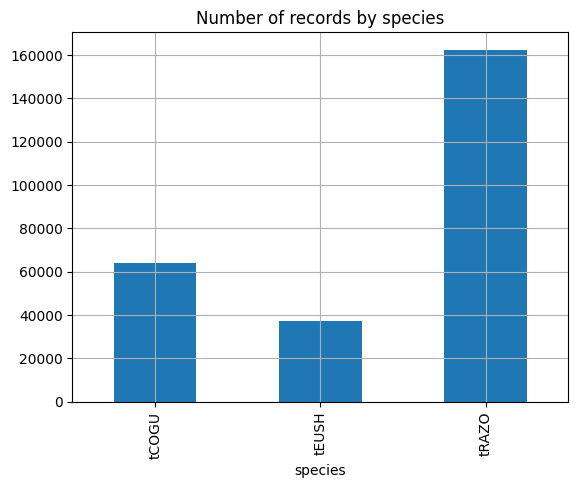

In [4]:
#Se tienen tres especies: Razorbill, Common Guillemot, European Shag
print(df.species.value_counts())
#Plot
df.species.value_counts().sort_index().plot(kind='bar')
plt.grid()
plt.title('Number of records by species')
plt.show()

colony2
1     89131
2     43002
9     40166
6     33890
5     19335
7     13785
3     10996
10     6506
4      3674
8      3233
Name: count, dtype: int64


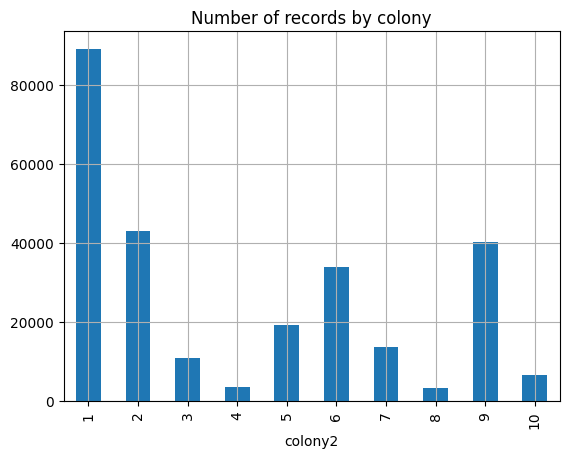

In [5]:
#Se tienen 10 colonias
print(df.colony2.value_counts())
#Plot
df.colony2.value_counts().sort_index().plot(kind='bar')
plt.grid()
plt.title('Number of records by colony')
plt.show()

In [6]:
#Se tienen 108 aves
df.bird.value_counts()

bird
104    6048
103    5889
100    5211
98     4532
44     4278
       ... 
93      985
82      916
86      903
81      897
5       506
Name: count, Length: 108, dtype: int64

year
t2012    95795
t2013    92372
t2014    49992
t2011    25559
Name: count, dtype: int64


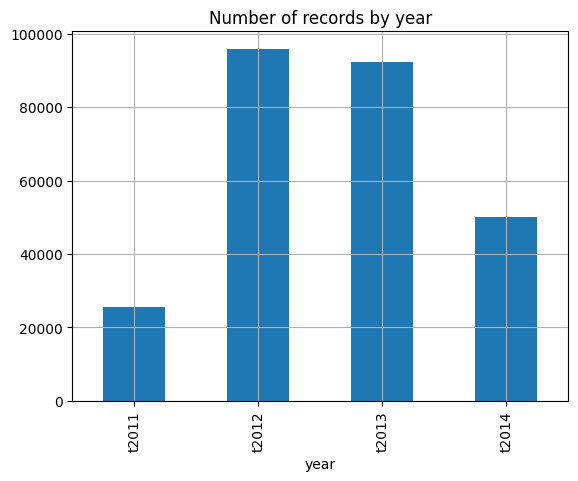

In [7]:
#Datos contemplados entre 2011 y 2014
print(df.year.value_counts())
#Plot
df.year.value_counts().sort_index().plot(kind='bar')
plt.grid()
plt.title('Number of records by year')
plt.show()

Conteo agrupado

colony2
1     33
2     16
3      7
4      2
5     12
6     16
7      7
8      1
9     10
10     4
Name: bird, dtype: int64


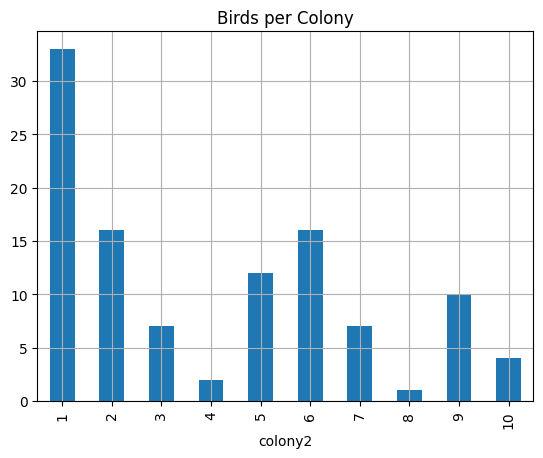

In [8]:
#Pájaros por Colonia
birds_per_colony = df.groupby(['colony2'])['bird'].nunique()
print(birds_per_colony)
birds_per_colony.plot(kind='bar')
plt.title('Birds per Colony')
plt.grid()
plt.show()

In [9]:
#Pájaros por Especie por Colonia
df.groupby(['colony2','species'])['bird'].nunique()

colony2  species
1        tCOGU      13
         tEUSH       2
         tRAZO      18
2        tCOGU       5
         tEUSH       2
         tRAZO       9
3        tCOGU       7
4        tEUSH       2
5        tRAZO      12
6        tEUSH       5
         tRAZO      11
7        tCOGU       2
         tEUSH       3
         tRAZO       2
8        tEUSH       1
9        tRAZO      10
10       tCOGU       4
Name: bird, dtype: int64

species
tCOGU    31
tEUSH    15
tRAZO    62
Name: bird, dtype: int64


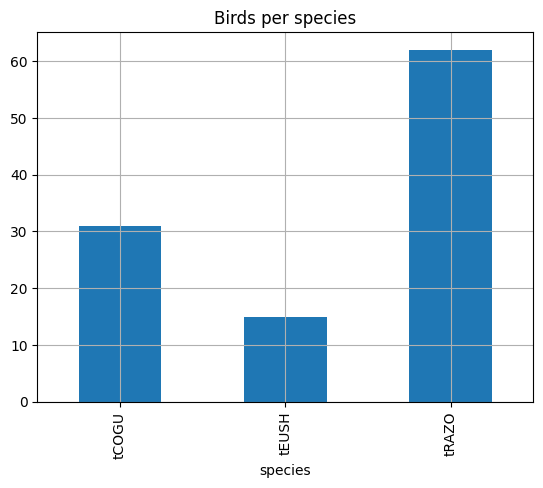

In [10]:
#Pájaros por Especie
birds_per_species = df.groupby(['species'])['bird'].nunique()
print(birds_per_species)
birds_per_species.plot(kind='bar')
plt.title('Birds per species')
plt.grid()
plt.show()

Identificación de zonas de interés

In [11]:
#Importar librerías necesarias
import folium 
from sklearn.cluster import KMeans

In [ ]:
#Número de clusters
num_clusters = 5

# Preparar los datos para K-Means
coordinates = df[['lat', 'lon']]

# Aplicar K-Means
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
df['cluster'] = kmeans.fit_predict(coordinates)

# Crear un mapa centrado en el promedio de las coordenadas
map_center = [df['lat'].mean(), df['lon'].mean()]
mapa = folium.Map(location=map_center, zoom_start=5)

# Colores para los clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Agregar puntos y clusters al mapa
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=colors[row['cluster']],
        fill=False,
    #    fill_opacity=0.9,
        popup=f"Cluster: {row['cluster']}",
    ).add_to(mapa)

# Mostrar el mapa
mapa

Filtrar puntos dentro de un área específica

In [ ]:
from geopy.distance import geodesic

# Centro del área de interés y radio en kilómetros
area_center = (df['lat'].mean(), df['lon'].mean())  # Promedio de las coordenadas
radius_km = 100

# Filtrar puntos dentro del radio
df['distance_km'] = df.apply(
    lambda row: geodesic((row['lat'], row['lon']), area_center).km, axis=1
)
filtered_data = df[df['distance_km'] <= radius_km]

# Mostrar puntos filtrados
print(filtered_data)

# Crear un mapa centrado en el promedio de las coordenadas
folium.Circle(
    location=area_center,
    radius=radius_km * 1000,  # Convertir a metros
    color='blue',
    fill=True,
    fill_opacity=0.3,
).add_to(mapa)

# Mostrar el mapa
mapa